# Part 1b: Price Paid Data audit (Oxfordshire, 2015–2025)

The same audit repeated on the five Oxfordshire districts over 11 years, downloaded from the Land Registry report builder (which uses a different column order from the bulk files). Includes the day-of-week check showing most sales complete on a Friday.

Findings and decisions: `logs/part_1_structural_anomalies.md`

#### Load data

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)


folder = Path('../data/raw')
file_gen = folder.glob('ppd_data*.csv')
df = pd.concat([pd.read_csv(f) for f in file_gen])

In [2]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 135557 entries, 0 to 23586
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   unique_id             135557 non-null  str  
 1   price_paid            135557 non-null  int64
 2   deed_date             135557 non-null  str  
 3   postcode              135115 non-null  str  
 4   property_type         135557 non-null  str  
 5   new_build             135557 non-null  str  
 6   estate_type           135557 non-null  str  
 7   saon                  11820 non-null   str  
 8   paon                  135557 non-null  str  
 9   street                132302 non-null  str  
 10  locality              57572 non-null   str  
 11  town                  135557 non-null  str  
 12  district              135557 non-null  str  
 13  county                135557 non-null  str  
 14  transaction_category  135557 non-null  str  
 15  linked_data_uri       135557 non-null  str  
dtypes

In [3]:
df.shape

(135557, 16)

Confirming Oxfordshire districts

In [4]:
df['district'].value_counts()

district
CHERWELL               33685
VALE OF WHITE HORSE    30710
SOUTH OXFORDSHIRE      29871
WEST OXFORDSHIRE       23587
OXFORD                 17704
Name: count, dtype: int64

#### Investigating anomalies

Checking datatypes

In [5]:
df.dtypes

unique_id                 str
price_paid              int64
deed_date                 str
postcode                  str
property_type             str
new_build                 str
estate_type               str
saon                      str
paon                      str
street                    str
locality                  str
town                      str
district                  str
county                    str
transaction_category      str
linked_data_uri           str
dtype: object

Looking at data consistency with types

In [6]:
df.head(5)

,unique_id,price_paid,deed_date,postcode,property_type,new_build,estate_type,saon,paon,street,locality,town,district,county,transaction_category,linked_data_uri
0,EED73E76-0354-6AF3-E053-6C04A8C08ABA,740000,2022-10-21,HP18 9UH,D,N,F,PARK COTTAGE,CHILLING PLACE FARM,NaN,BRILL,AYLESBURY,CHERWELL,OXFORDSHIRE,A,http://landregistry.data.gov.uk/data/ppi/trans...
1,5340B1C6-2D3F-8052-E063-4804A8C06EE4,1000000,2025-11-07,HP18 9UY,O,N,F,NaN,OAKCROFT FARM,NaN,BOARSTALL,AYLESBURY,CHERWELL,OXFORDSHIRE,B,http://landregistry.data.gov.uk/data/ppi/trans...
2,49E87C32-EBB0-591C-E063-4704A8C00C31,725000,2025-04-28,HP18 9UZ,O,N,F,NaN,TUTHER CORNER,NaN,BRILL,AYLESBURY,CHERWELL,OXFORDSHIRE,B,http://landregistry.data.gov.uk/data/ppi/trans...
3,726BF13B-2877-0A46-E053-6C04A8C01D0D,350000,2017-07-14,HP18 9UZ,D,N,F,NaN,TUTHER CORNER,NaN,BRILL,AYLESBURY,CHERWELL,OXFORDSHIRE,A,http://landregistry.data.gov.uk/data/ppi/trans...
4,1061746E-55C9-3C34-E063-4804A8C0F9E7,675000,2022-09-01,HP18 9XA,D,N,F,HEADLEY HOUSE,PIDDINGTON GATE FARM,NaN,BRILL,AYLESBURY,CHERWELL,OXFORDSHIRE,A,http://landregistry.data.gov.uk/data/ppi/trans...


Checking null and unique values

In [7]:

print(pd.concat([df.nunique(), df.isna().sum()], axis=1, keys=['unique', 'null']))
print(df.duplicated().sum())

                      unique    null
unique_id             135557       0
price_paid              8779       0
deed_date               3002       0
postcode               16536     442
property_type              5       0
new_build                  2       0
estate_type                2       0
saon                    1151  123737
paon                   11542       0
street                  8178    3255
locality                 496   77985
town                      26       0
district                   5       0
county                     1       0
transaction_category       2       0
linked_data_uri       135557       0
0


Looking at min/max price

In [8]:
print(df['price_paid'].sort_values())
print((df['price_paid'] < 1000).sum())
print((df['price_paid'] > 100000000).sum())

7836           100
10854          100
18033          100
11946          100
260            100
           ...    
13323     88667040
5095      89914102
1473      91489547
19316     92555918
16536    414108660
Name: price_paid, Length: 135557, dtype: int64
20
1


Inspect values of street, town_city, locality, district, county

Searching for unexpected characters

In [9]:
to_check = ['street', 'town', 'locality', 'district', 'county']
for n in to_check:
    print(f"Checking {n} : contains {df[n].str.count(r"[^&a-zA-Z0-9'.\s-]").sum()} special or accented characters excl -'&.")


Checking street : contains 0.0 special or accented characters excl -'&.
Checking town : contains 0 special or accented characters excl -'&.
Checking locality : contains 0.0 special or accented characters excl -'&.
Checking district : contains 0 special or accented characters excl -'&.
Checking county : contains 0 special or accented characters excl -'&.


Testing regex search

In [10]:
import re
test = "!£$%^&*()<>?/@|¬"

re.findall(r"[^&a-zA-Z0-9'.\s-]", test)

['!', '£', '$', '%', '^', '*', '(', ')', '<', '>', '?', '/', '@', '|', '¬']

Looking at actual flagged values

In [11]:
for n in to_check:
    print(df[n][df[n].str.contains(r"[^&a-zA-Z0-9'.\s-]")].value_counts())


Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


A list of the unique special characters being found

In [12]:

results = set()
for n in to_check:
    flagged_rows = df[n][df[n].str.contains(r"[^&a-zA-Z0-9'.\s-]")]
    for r in flagged_rows:
       matches = re.findall(r"[^&a-zA-Z0-9'.\s-]", r)
       results.update(matches)
print(results)



set()


Postcode check on structure

In [13]:
print(f"Postcodes between {df['postcode'].str.len().max()} and {df['postcode'].str.len().min()} characters in length")


passed_postcodes = df['postcode'].str.match(r"^[A-Z]{1,2}\d[A-Z0-9]? \d[A-Z]{2}$", na=False).sum()
total_postcodes = df['postcode'].dropna().count()
print(f"{total_postcodes - passed_postcodes} postcodes failed the regex check")
print(df['postcode'][~df['postcode'].str.match(r"^[A-Z]{1,2}\d[A-Z0-9]? \d[A-Z]{2}$", na=True)])

Postcodes between 8.0 and 7.0 characters in length
0 postcodes failed the regex check
Series([], Name: postcode, dtype: str)


year   2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
month                                                                  
1        22    21    24    24    26    24    28    23    25    25    23
2        21    22    20    21    21    21    23    24    20    22    20
3        23    23    24    26    22    25    28    24    24    23    24
4        22    23    20    21    21    22    23    20    23    22    21
5        20    20    22    22    22    22    22    25    21    23    22
6        24    24    24    23    22    25    27    22    22    23    22
7        24    22    23    23    24    25    24    22    22    25    24
8        24    23    24    22    24    20    22    23    24    24    21
9        24    22    22    23    22    22    25    24    23    25    22
10       26    22    24    24    23    25    22    25    22    23    23
11       23    24    23    23    22    24    22    22    24    22    21
12       22    22    20    21    20    23    23    21    19    1

<Axes: xlabel='month'>

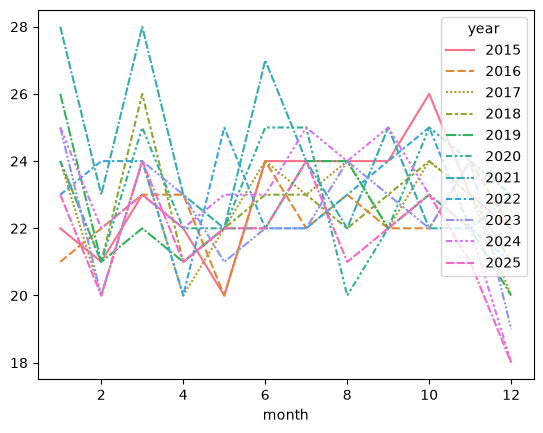

In [14]:
# print(df['deed_date'].sort_values())
df['deed_date'] = df['deed_date'].astype('datetime64[s]')
dates = pd.DataFrame()
df['day'] = df['deed_date'].dt.day
df['month'] = df['deed_date'].dt.month
df['year'] = df['deed_date'].dt.year
df['dayofweek'] = df['deed_date'].dt.dayofweek

dates = df.groupby(['month', 'year'])['day'].nunique()
print(dates.unstack())

dow = df.groupby(['dayofweek'])['unique_id'].nunique().to_frame(name='unique_count')
dow['percentage'] = round((dow['unique_count']/dow['unique_count'].sum())*100, 1)
print(dow)
sns.lineplot(dates.unstack())